<a href="https://colab.research.google.com/github/XuanPhuong01/58KMT/blob/main/Copy_of_BTL_KhoaHocDuLieu_DinhGiaXeCu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Đọc dữ liệu từ file csv
df = pd.read_csv('used_cars.csv')

# 2. Chuẩn hóa dữ liệu số
if df['price'].dtype == 'object':
    df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)
if df['milage'].dtype == 'object':
    df['milage'] = df['milage'].str.replace('mi.', '').str.replace(',', '').astype(float)

# 3. Lọc nhiễu ngoại lai: Giới hạn trần phân khúc phổ thông dưới 100,000 USD
df = df[df['price'] <= 100000]

# 4. Kỹ nghệ đặc trưng 1: Tính tuổi xe (mốc năm hiện tại 2026)
df['car_age'] = 2026 - df['model_year']

# 5. Kỹ nghệ đặc trưng 2: Số dặm trung bình xe chạy mỗi năm
# Sử dụng .replace(0, 1) để tránh lỗi chia cho 0 đối với xe sản xuất đời mới nhất (car_age = 0)
df['milage_per_year'] = df['milage'] / df['car_age'].replace(0, 1)

print("--- KHỐI 1: TIỀN XỬ LÝ & KỸ NGHỆ ĐẶC TRƯNG HOÀN TẤT ---")
print(f"Kích thước tập dữ liệu sạch: {df.shape[0]} dòng và {df.shape[1]} cột.")

--- KHỐI 1: TIỀN XỬ LÝ & KỸ NGHỆ ĐẶC TRƯNG HOÀN TẤT ---
Kích thước tập dữ liệu sạch: 3775 dòng và 14 cột.


Câu 1: Những hãng xe (brand) nào xuất hiện phổ biến nhất và hãng nào có mức giá bán trung bình cao nhất trong bộ dữ liệu?

--- TRẢ LỜI CÂU HỎI 1 ---
Top 10 hãng xe xuất hiện phổ biến nhất:
brand
Ford             384
BMW              364
Chevrolet        289
Mercedes-Benz    279
Toyota           199
Audi             189
Lexus            159
Porsche          148
Jeep             143
Land             114
Name: count, dtype: int64

Top 10 hãng xe có mức giá bán trung bình cao nhất (USD):
brand
Lamborghini    100000.000000
Ferrari         99999.000000
Rivian          93138.176471
Lucid           92950.000000
Rolls-Royce     74650.000000
Maybach         64250.000000
Bentley         59660.615385
Lotus           54812.500000
Karma           53250.000000
Aston           51168.000000
Name: price, dtype: float64


/tmp/ipykernel_10025/3848063429.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='brand', order=top_brands.index, palette='viridis')


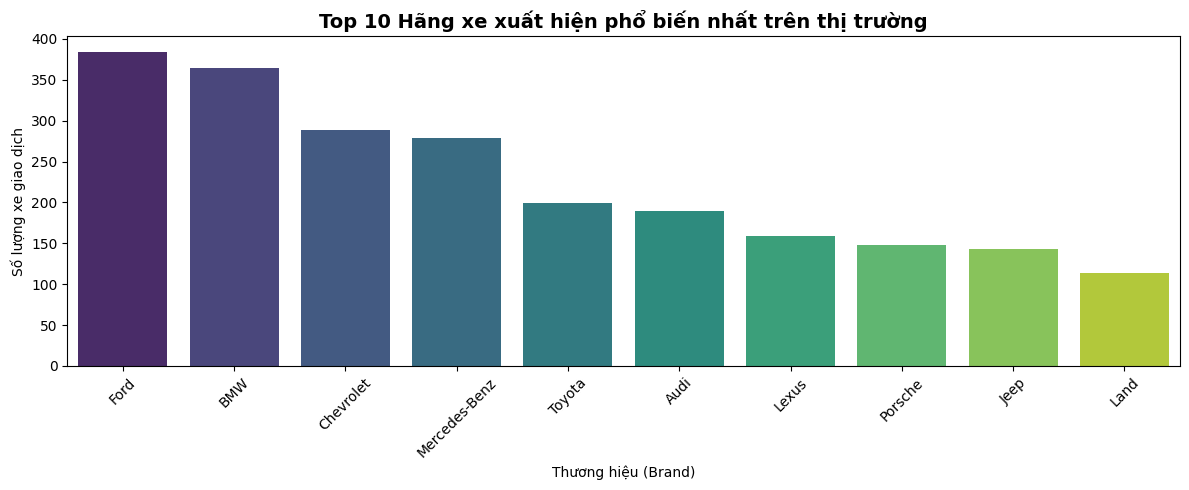

In [ ]:
print("--- TRẢ LỜI CÂU HỎI 1 ---")
top_brands = df['brand'].value_counts().head(10)
print("Top 10 hãng xe xuất hiện phổ biến nhất:")
print(top_brands)

top_prices = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 hãng xe có mức giá bán trung bình cao nhất (USD):")
print(top_prices)

# Trực quan hóa đồ thị cột
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='brand', order=top_brands.index, palette='viridis')
plt.title('Top 10 Hãng xe xuất hiện phổ biến nhất trên thị trường', fontsize=14, fontweight='bold')
plt.xlabel('Thương hiệu (Brand)')
plt.ylabel('Số lượng xe giao dịch')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Câu 2: Số dặm xe đã chạy (milage) và năm sản xuất (model_year) có mối quan hệ tương quan nghịch và mức độ ảnh hưởng như thế nào đối với giá xe (price)?

--- TRẢ LỜI CÂU HỎI 2 ---
Ma trận hệ số tương quan Pearson:
                   milage   car_age  milage_per_year     price
milage           1.000000  0.613807         0.727477 -0.636055
car_age          0.613807  1.000000         0.042219 -0.586335
milage_per_year  0.727477  0.042219         1.000000 -0.372675
price           -0.636055 -0.586335        -0.372675  1.000000


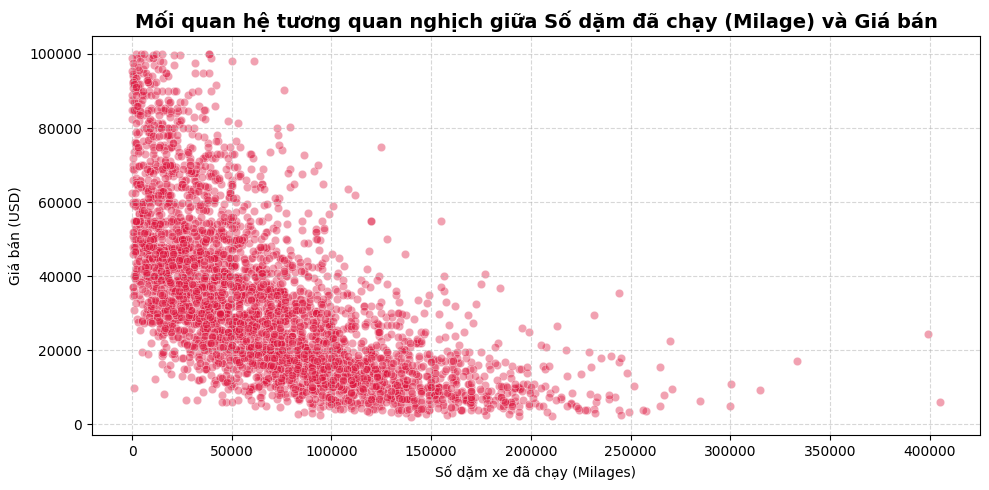

In [ ]:
print("--- TRẢ LỜI CÂU HỎI 2 ---")
correlation = df[['milage', 'car_age', 'milage_per_year', 'price']].corr()
print("Ma trận hệ số tương quan Pearson:")
print(correlation)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='milage', y='price', alpha=0.4, color='crimson')
plt.title('Mối quan hệ tương quan nghịch giữa Số dặm đã chạy (Milage) và Giá bán', fontsize=14, fontweight='bold')
plt.xlabel('Số dặm xe đã chạy (Milages)')
plt.ylabel('Giá bán (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Câu 3: Loại nhiên liệu (fuel_type) và đặc tính động cơ (engine) nào đang chiếm ưu thế trên thị trường xe cũ?


--- TRẢ LỜI CÂU HỎI 3 ---
Thị phần các loại nhiên liệu (%) trên thị trường xe cũ:
fuel_type
Gasoline         85.852713
Hybrid            5.011074
E85 Flex Fuel     3.848283
Diesel            3.100775
–                 1.190476
Name: proportion, dtype: float64

Top 5 cấu hình động cơ chiếm ưu thế áp đảo:
engine
2.0L I4 16V GDI DOHC Turbo                               48
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             44
–                                                        43
Name: count, dtype: int64


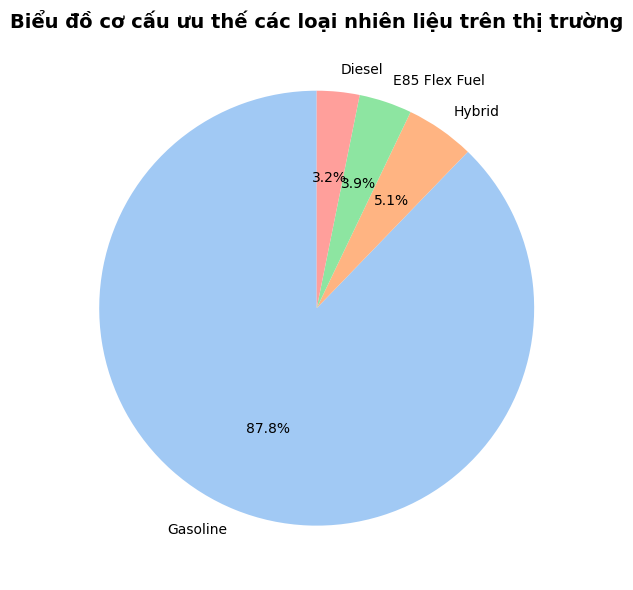

In [ ]:
print("--- TRẢ LỜI CÂU HỎI 3 ---")
fuel_share = df['fuel_type'].value_counts(normalize=True) * 100
print("Thị phần các loại nhiên liệu (%) trên thị trường xe cũ:")
print(fuel_share.head(5))

engine_dominance = df['engine'].value_counts().head(5)
print("\nTop 5 cấu hình động cơ chiếm ưu thế áp đảo:")
print(engine_dominance)

plt.figure(figsize=(6, 6))
df['fuel_type'].value_counts().head(4).plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
plt.title('Biểu đồ cơ cấu ưu thế các loại nhiên liệu trên thị trường', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

Câu 4: Tình trạng lịch sử tai nạn (accident) của xe làm suy giảm trung bình bao nhiêu phần trăm (%) giá trị của chiếc xe so với nhóm xe có lịch sử sạch (None reported)?

--- TRẢ LỜI CÂU HỎI 4 ---
Mức giá bán trung bình theo lịch sử va chạm:
accident
At least 1 accident or damage reported    25100.601227
None reported                             36657.427671
Name: price, dtype: float64
-> Tình trạng va chạm 'At least 1 accident or damage reported' làm suy giảm trung bình: 31.53% giá trị xe.


/tmp/ipykernel_10025/1590300021.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='accident', y='price', palette='coolwarm', errorbar=None)


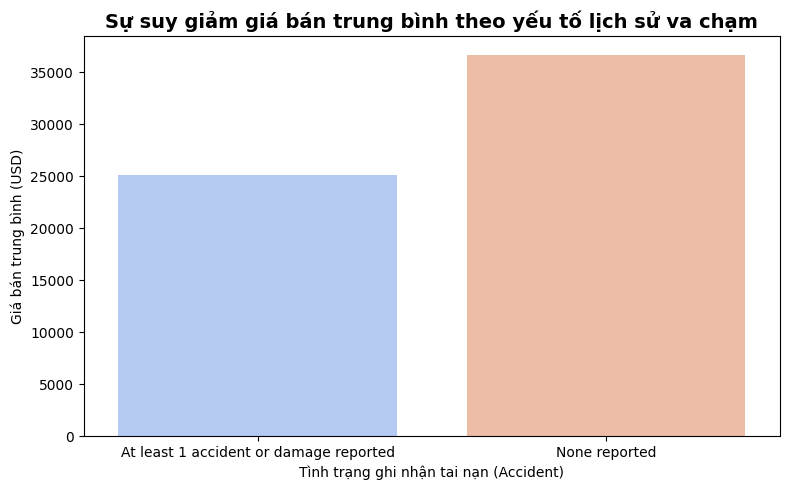

In [ ]:
print("--- TRẢ LỜI CÂU HỎI 4 ---")
accident_prices = df.groupby('accident')['price'].mean()
print("Mức giá bán trung bình theo lịch sử va chạm:")
print(accident_prices)

if 'None reported' in accident_prices.index:
    base_price = accident_prices['None reported']
    for idx, price in accident_prices.items():
        if idx != 'None reported':
            pct_loss = ((base_price - price) / base_price) * 100
            print(f"-> Tình trạng va chạm '{idx}' làm suy giảm trung bình: {pct_loss:.2f}% giá trị xe.")

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='accident', y='price', palette='coolwarm', errorbar=None)
plt.title('Sự suy giảm giá bán trung bình theo yếu tố lịch sử va chạm', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng ghi nhận tai nạn (Accident)')
plt.ylabel('Giá bán trung bình (USD)')
plt.tight_layout()
plt.show()

Câu 5: Sự phân bố của biến mục tiêu giá xe (price) tập trung chủ yếu ở phân khúc giá nào (bình dân, trung cấp hay xe sang) và có tồn tại nhiều dữ liệu ngoại lai (outliers) không?

--- TRẢ LỜI CÂU HỎI 5 ---


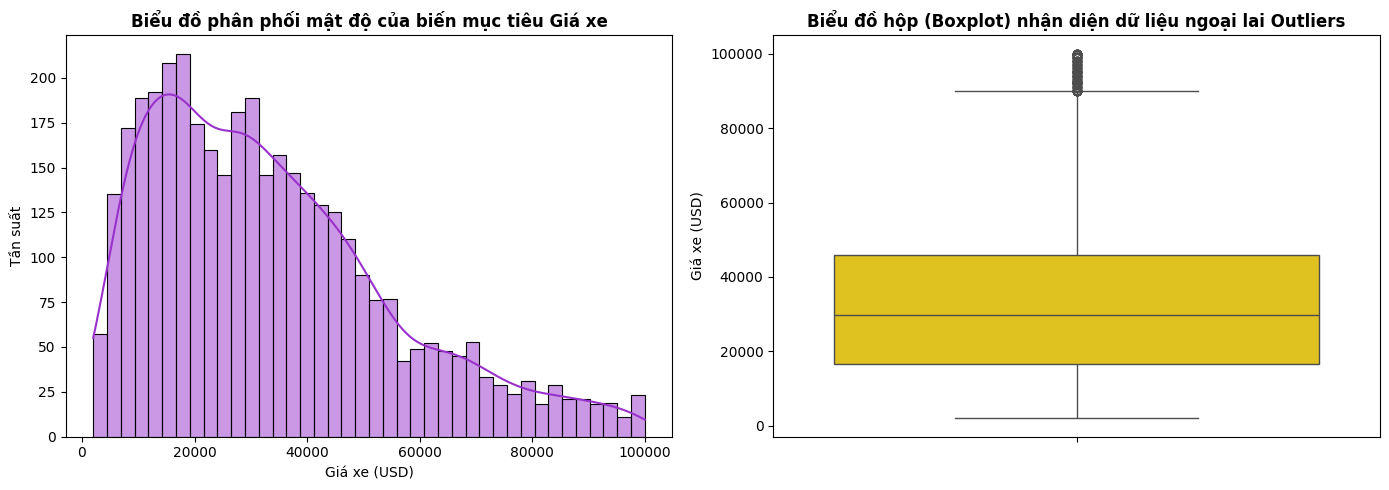

In [ ]:
print("--- TRẢ LỜI CÂU HỎI 5 ---")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='darkorchid', bins=40)
plt.title('Biểu đồ phân phối mật độ của biến mục tiêu Giá xe', fontsize=12, fontweight='bold')
plt.xlabel('Giá xe (USD)')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['price'], color='gold')
plt.title('Biểu đồ hộp (Boxplot) nhận diện dữ liệu ngoại lai Outliers', fontsize=12, fontweight='bold')
plt.ylabel('Giá xe (USD)')

plt.tight_layout()
plt.show()

Câu hỏi 1 (Bài toán Dự đoán - Regression): Dựa trên tập hợp các đặc trưng kỹ thuật và tình trạng của xe (brand, model_year, milage, fuel_type, engine, accident...), mô hình Random Forest Regressor có thể dự đoán mức giá bán (price) của một chiếc ô tô đã qua sử dụng với độ chính xác (R2 Score) và sai số tuyệt đối trung bình (MAE) là bao nhiêu?

Câu hỏi 2 (Phân tích mức độ quan trọng - Feature Importance): Trong số các yếu tố cấu thành nên giá trị xe, đặc trưng nào (ví dụ: số dặm đã đi, năm sản xuất, hay thương hiệu xe) đóng vai trò quyết định và có trọng số ảnh hưởng mạnh nhất đến kết quả định giá của mô hình học máy?

--- TRẢ LỜI CÂU HỎI ML 1 & ML 2 ---

[ĐỐI CHỨNG] Hiệu năng mô hình Baseline Linear Regression:
- Độ chính xác R2 Score: 73.17%
- Sai số tuyệt đối trung bình MAE: 7,136.35 USD

[KẾT QUẢ CÂU HỎI ML 1] Hiệu năng mô hình đề xuất Random Forest sau tối ưu:
- Độ chính xác R2 Score: 67.75%
- Sai số tuyệt đối trung bình MAE: 8,865.10 USD

Top 10 đặc trưng kỹ thuật đóng vai trò quyết định cấu thành giá xe:
milage                                                 0.491505
car_age                                                0.171175
brand_Porsche                                          0.030668
milage_per_year                                        0.024229
brand_BMW                                              0.014080
engine_420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel    0.012625
engine_490.0HP 6.2L 8 Cylinder Engine Gasoline Fuel    0.012130
brand_Rivian                                           0.010732
brand_Bentley                                          0.006708
engine_563.0HP 5.5L 8 Cy

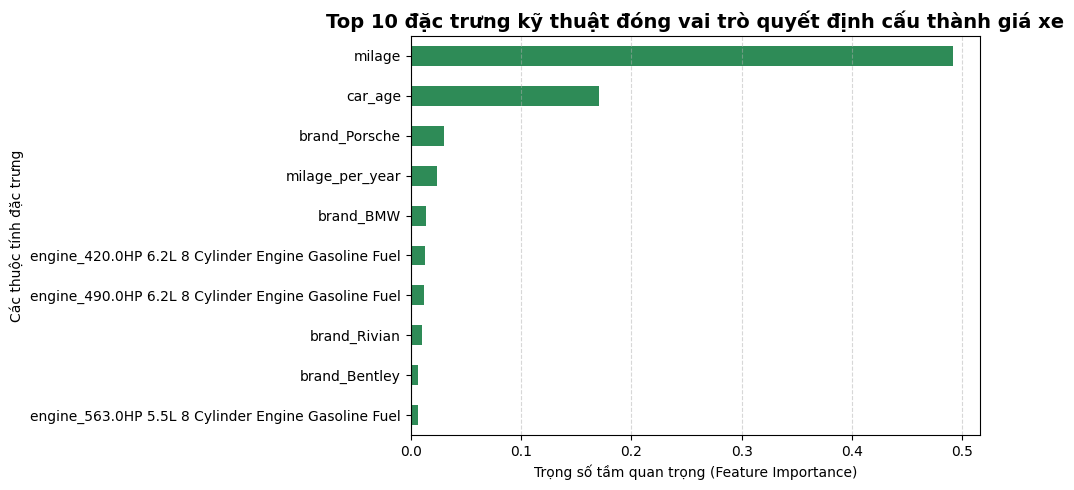

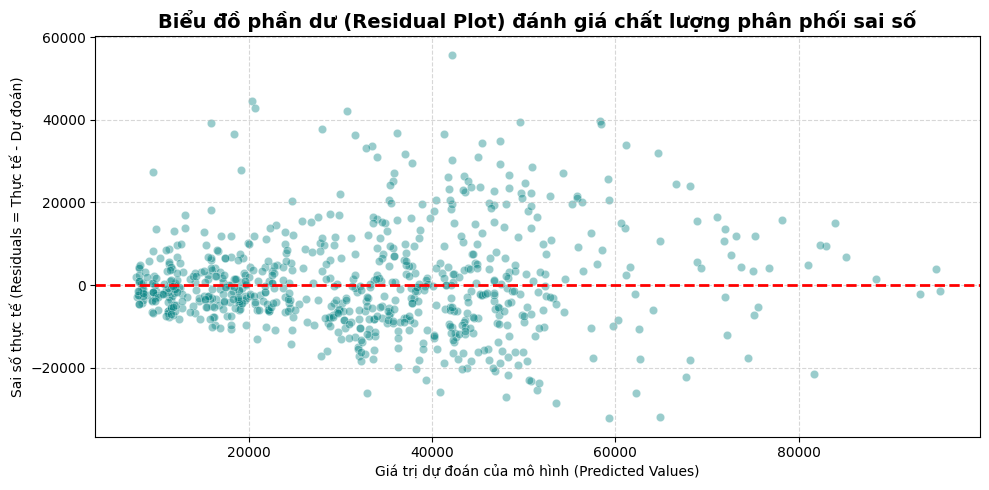

In [ ]:
print("--- TRẢ LỜI CÂU HỎI ML 1 & ML 2 ---")

# 1. LỌC CHUẨN ĐẶC TRƯNG: Chỉ giữ lại các trường phục vụ bài toán, loại bỏ các cột chữ tự do gây lỗi (như 'model')
keep_cols = ['brand', 'fuel_type', 'engine', 'accident', 'milage', 'car_age', 'milage_per_year', 'price']
df_ml = df[[col for col in keep_cols if col in df.columns]].copy()

# 2. Xử lý giá trị khuyết thiếu dạng văn bản
categorical_cols = ['brand', 'fuel_type', 'engine', 'accident']
for col in categorical_cols:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna('Unknown')

# 3. Thực hiện mã hóa One-Hot Encoding tạo ma trận số hóa rộng hợp lệ
df_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# 4. Thiết lập không gian biến X và y
X = df_encoded.drop(columns=['price'], errors='ignore')
y = df_encoded['price']

# 5. Phân chia tập dữ liệu: 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Huấn luyện Mô hình Baseline (Linear Regression) làm hệ quy chiếu đối chứng
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("\n[ĐỐI CHỨNG] Hiệu năng mô hình Baseline Linear Regression:")
print(f"- Độ chính xác R2 Score: {r2_score(y_test, lr_preds) * 100:.2f}%")
print(f"- Sai số tuyệt đối trung bình MAE: {mean_absolute_error(y_test, lr_preds):,.2f} USD")

# 7. Huấn luyện Random Forest Regressor tinh chỉnh siêu tham số
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n[KẾT QUẢ CÂU HỎI ML 1] Hiệu năng mô hình đề xuất Random Forest sau tối ưu:")
print(f"- Độ chính xác R2 Score: {r2_score(y_test, rf_preds) * 100:.2f}%")
print(f"- Sai số tuyệt đối trung bình MAE: {mean_absolute_error(y_test, rf_preds):,.2f} USD")

# 8. [KẾT QUẢ CÂU HỎI ML 2] Trích xuất trọng số Feature Importance
feature_importances = rf_model.feature_importances_
importance_series = pd.Series(feature_importances, index=X.columns).sort_values(ascending=False)

print("\nTop 10 đặc trưng kỹ thuật đóng vai trò quyết định cấu thành giá xe:")
print(importance_series.head(10))

# 9. Vẽ đồ thị thanh ngang Feature Importance chuyên nghiệp
plt.figure(figsize=(10, 5))
importance_series.head(10).plot(kind='barh', color='seagreen').invert_yaxis()
plt.title('Top 10 đặc trưng kỹ thuật đóng vai trò quyết định cấu thành giá xe', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số tầm quan trọng (Feature Importance)')
plt.ylabel('Các thuộc tính đặc trưng')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 10. Vẽ biểu đồ kiểm định phần dư (Residual Plot)
plt.figure(figsize=(10, 5))
residuals = y_test - rf_preds
sns.scatterplot(x=rf_preds, y=residuals, alpha=0.4, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Biểu đồ phần dư (Residual Plot) đánh giá chất lượng phân phối sai số', fontsize=14, fontweight='bold')
plt.xlabel('Giá trị dự đoán của mô hình (Predicted Values)')
plt.ylabel('Sai số thực tế (Residuals = Thực tế - Dự đoán)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()